## COVID Drivers: Modeling

This notebook models
POST_COVID ~ AGGRESSIVE_DRIVING

### Table of Contents
* [Read the Data](#read)</BR>
* [Preprocessing](#prep)</BR>
* [XGBoost](#xgb)</BR>
* [XGBoost with GridSearchCV](#xgb-gs)</BR>
* [Review Models](#review)


Import packages

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

import xgboost as xgb
from functools import reduce
#import prince

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, classification_report

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
path_in = '/content/drive/MyDrive/Colab Notebooks/Case Studies in Data Science/data/ready/ready_data.csv'

In [4]:
path_out = 'metrics_06_prim_modl_xgb.csv'

### <a id='read'>Read the data</a>

In [5]:
df_init = pd.read_csv(path_in, low_memory=False)

In [6]:
df_init['CRASH_DATE'] = pd.to_datetime(df_init['CRASH_DATE'])

In [7]:
df = df_init.set_index('CRASH_DATE').drop(columns=['CRN']).copy()

In [8]:
model_metrics = []

In [9]:
df.columns.tolist()

['POST_COVID',
 'ALCOHOL_RELATED',
 'CELL_PHONE',
 'DISTRACTED',
 'DRINKING_DRIVER',
 'DRIVER_16YR',
 'DRIVER_17YR',
 'DRIVER_18YR',
 'DRIVER_19YR',
 'DRIVER_20YR',
 'DRIVER_50_64YR',
 'DRIVER_65_74YR',
 'DRIVER_75PLUS',
 'DRUGGED_DRIVER',
 'DRUG_RELATED',
 'FATIGUE_ASLEEP',
 'HIT_RUN',
 'ILLEGAL_DRUG_RELATED',
 'IMPAIRED_DRIVER',
 'IMPAIRED_NONMOTORIST',
 'MARIJUANA_DRUGGED_DRIVER',
 'MARIJUANA_RELATED',
 'MATURE_DRIVER',
 'MC_DRINKING_DRIVER',
 'OPIOID_RELATED',
 'UNDERAGE_DRNK_DRV',
 'UNLICENSED',
 'YOUNG_DRIVER',
 'AGGRESSIVE_DRIVING',
 'NHTSA_AGG_DRIVING',
 'NO_CLEARANCE',
 'RUNNING_RED_LT',
 'RUNNING_STOP_SIGN',
 'SPEEDING',
 'SPEEDING_RELATED',
 'TAILGATING',
 'COUNTYx',
 'URBAN_RURALx']

### <a id='prep'>Preprocessing</a>

In [10]:
X = df.loc[:,['POST_COVID']].copy()

In [11]:
y = df['AGGRESSIVE_DRIVING']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

### <a id='xgb'>XGBoost</a>

In [13]:
xgb_pipeline = Pipeline(steps=[
    ('xgboost', xgb.XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        objective='binary:logistic'
     ))
])

In [14]:
xgb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('xgboost',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric=None,
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=100, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [15]:
y_pred = xgb_pipeline.predict(X_test)

In [16]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 55.98%


In [17]:
conf_matrix = confusion_matrix(y_test, y_pred)

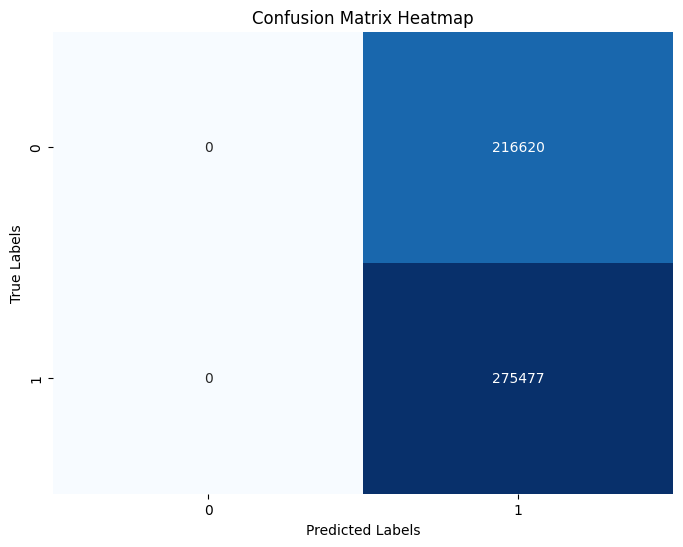

In [18]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', cbar=False)

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [19]:
# Predicted probabilities for the class 1
y_pred_proba = xgb_pipeline.predict_proba(X_test)[:, 1]

In [20]:
# Precision: tp / (tp + fp)
precision = precision_score(y_test, y_pred)

In [21]:
# Recall: tp / (tp + fn)
recall = recall_score(y_test, y_pred)

In [22]:
# F1-score: harmonic mean of precision and recall
f1 = f1_score(y_test, y_pred)

In [23]:
# ROC AUC: Area Under the Receiver Operating Characteristic Curve
roc_auc = roc_auc_score(y_test, y_pred_proba)

In [24]:
measure_titles = ['Accuracy','Precision','Recall','F1 Score','ROC AUC']
measure_value = [accuracy,precision,recall,f1,roc_auc]
model = 'XGBoost'

In [25]:
aggdrv_xgb = pd.DataFrame({'Measure':measure_titles,
                            model:measure_value})

In [26]:
aggdrv_xgb['XGBoost'] = [round(x, 4) for x in aggdrv_xgb['XGBoost']]

In [27]:
aggdrv_xgb

,Measure,XGBoost
0,Accuracy,0.5598
1,Precision,0.5598
2,Recall,1.0000
3,F1 Score,0.7178
4,ROC AUC,0.5030


In [28]:
model_metrics.append(aggdrv_xgb)

### <a id='xgb-gs'>XGBoost with GridSearchCV</a>

In [29]:
# Number of trees in random forest
n_estimators = [100, 1000]
# Maximum number of levels in tree
max_depth = [None, 5, 10]
# Step size at each boosting iteration
learning_rate = [0.01, 0.2]
# Minimum sum of instance weight (hessian) required in a child node
min_child_weight = [0, 1]
# Minimum loss reduction required to make a further partition on a leaf node of the tree - gamma
min_split_loss = [0, 0.1]
# Method of selecting samples for training each tree
subsample = [0.5, 1]
# L2 regularization term on weights
reg_lambda = [1, 2]
# L1 regularization term on weights
reg_alpha = [0, 1]

# Create the random grid
param_grid = {'clf__max_depth': max_depth,
               'clf__learning_rate': learning_rate,
               'clf__min_child_weight': min_child_weight,
               'clf__min_split_loss': min_split_loss,
               'clf__subsample': subsample,
               'clf__reg_lambda': reg_lambda,
               'clf__reg_alpha': reg_alpha}

In [30]:
clf_pipeline = Pipeline([
    ('clf', xgb.XGBClassifier(n_estimators=1000, early_stopping_rounds=10, random_state=42))
])

In [31]:
grid_search = GridSearchCV(clf_pipeline,
                            param_grid=param_grid,
                            cv=5,
                            scoring='f1',
                            return_train_score=True,
                            refit=True,
                            verbose=1)

In [32]:
grid_search.fit(
    X_train, y_train,
    clf__eval_set=[(X_test, y_test)]
)

Streaming output truncated to the last 5000 lines.
[6]	validation_0-logloss:0.68595
[7]	validation_0-logloss:0.68595
[8]	validation_0-logloss:0.68595
[9]	validation_0-logloss:0.68595
[10]	validation_0-logloss:0.68595
[11]	validation_0-logloss:0.68595
[12]	validation_0-logloss:0.68595
[13]	validation_0-logloss:0.68595
[14]	validation_0-logloss:0.68595
[15]	validation_0-logloss:0.68595
[16]	validation_0-logloss:0.68595
[17]	validation_0-logloss:0.68595
[18]	validation_0-logloss:0.68595
[19]	validation_0-logloss:0.68595
[20]	validation_0-logloss:0.68595
[21]	validation_0-logloss:0.68595
[22]	validation_0-logloss:0.68595
[23]	validation_0-logloss:0.68595
[24]	validation_0-logloss:0.68595
[25]	validation_0-logloss:0.68595
[0]	validation_0-logloss:0.68597
[1]	validation_0-logloss:0.68596
[2]	validation_0-logloss:0.68596
[3]	validation_0-logloss:0.68596
[4]	validation_0-logloss:0.68595
[5]	validation_0-logloss:0.68595
[6]	validation_0-logloss:0.68595
[7]	validation_0-logloss:0.68595
[8]	valid

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('clf',
                                        XGBClassifier(base_score=None,
                                                      booster=None,
                                                      callbacks=None,
                                                      colsample_bylevel=None,
                                                      colsample_bynode=None,
                                                      colsample_bytree=None,
                                                      device=None,
                                                      early_stopping_rounds=10,
                                                      enable_categorical=False,
                                                      eval_metric=None,
                                                      feature_types=None,
                                                      feature_weights=None,
                                                      gamma=None,
                                                      grow_policy=None,
                                                      importance_type=None,
                                                      intera...
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=1000,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             param_grid={'clf__learning_rate': [0.01, 0.2],
                         'clf__max_depth': [None, 5, 10],
                         'clf__min_child_weight': [0, 1],
                         'clf__min_split_loss': [0, 0.1],
                         'clf__reg_alpha': [0, 1], 'clf__reg_lambda': [1, 2],
                         'clf__subsample': [0.5, 1]},
             return_train_score=True, scoring='f1', verbose=1)

In [33]:
y_pred = grid_search.predict(X_test)

In [34]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 55.98%


In [35]:
conf_matrix = confusion_matrix(y_test, y_pred)

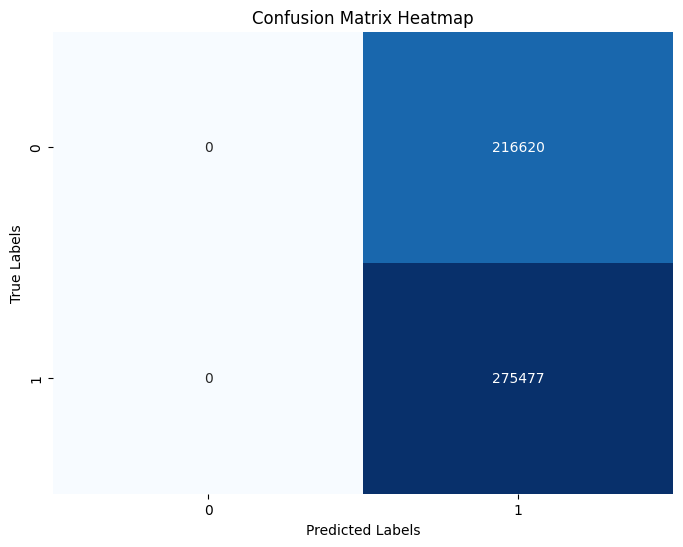

In [36]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', cbar=False)

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [37]:
# Predicted probabilities for the class 1
y_pred_proba = grid_search.predict_proba(X_test)[:, 1]

In [38]:
# Precision: tp / (tp + fp)
precision = precision_score(y_test, y_pred)

In [39]:
# Recall: tp / (tp + fn)
recall = recall_score(y_test, y_pred)

In [40]:
# F1-score: harmonic mean of precision and recall
f1 = f1_score(y_test, y_pred)

In [41]:
# ROC AUC: Area Under the Receiver Operating Characteristic Curve
roc_auc = roc_auc_score(y_test, y_pred_proba)

In [42]:
measure_titles = ['Accuracy','Precision','Recall','F1 Score','ROC AUC']
measure_value = [accuracy,precision,recall,f1,roc_auc]
model = 'XGBoost_GridSearchCV'

In [43]:
aggdrv_xgbgs = pd.DataFrame({'Measure':measure_titles,
                            model:measure_value})

In [44]:
aggdrv_xgbgs['XGBoost_GridSearchCV'] = [round(x, 4) for x in aggdrv_xgbgs['XGBoost_GridSearchCV']]

In [45]:
aggdrv_xgbgs

,Measure,XGBoost_GridSearchCV
0,Accuracy,0.5598
1,Precision,0.5598
2,Recall,1.0000
3,F1 Score,0.7178
4,ROC AUC,0.5030


In [46]:
model_metrics.append(aggdrv_xgbgs)

### <a id='review'>Review Models</a>

In [47]:
merged_metrics = reduce(lambda left, right: pd.merge(left, right, on='Measure', how='inner'), model_metrics)

In [48]:
merged_metrics

,Measure,XGBoost,XGBoost_GridSearchCV
0,Accuracy,0.5598,0.5598
1,Precision,0.5598,0.5598
2,Recall,1.0000,1.0000
3,F1 Score,0.7178,0.7178
4,ROC AUC,0.5030,0.5030


In [49]:
merged_metrics.to_csv(path_out, index=False)